### **EXPLORE DATASET**

In [1]:
import pandas as pd
from datasets import load_dataset, Dataset
from pathlib import Path
import json
from lingua import Language, LanguageDetectorBuilder

#### **loading dataset to explore**

In [2]:
# function to read dataset

def dataset_generator():
    dataset_path = Path.cwd().parent / "datasets/raw_dataset.jsonl"
    with open(dataset_path, 'r') as f:
        for line in f:
            if line.strip():
                yield json.loads(line)['_source']


In [3]:
# load dataset from the generator above
raw_dataset = Dataset.from_generator(dataset_generator)
raw_dataset

Dataset({
    features: ['product', 'complaint_what_happened', 'date_sent_to_company', 'issue', 'sub_product', 'zip_code', 'tags', 'complaint_id', 'timely', 'company_response', 'submitted_via', 'company', 'date_received', 'state', 'company_public_response', 'sub_issue'],
    num_rows: 22968
})

In [4]:
# information found in the dataset
raw_dataset.column_names

['product',
 'complaint_what_happened',
 'date_sent_to_company',
 'issue',
 'sub_product',
 'zip_code',
 'tags',
 'complaint_id',
 'timely',
 'company_response',
 'submitted_via',
 'company',
 'date_received',
 'state',
 'company_public_response',
 'sub_issue']

In [5]:
# get data in pandas for easy exploration
raw_dataset.set_format("pandas")
df = raw_dataset[:]

In [6]:
# structure/columns of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22968 entries, 0 to 22967
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   product                  22968 non-null  object
 1   complaint_what_happened  22968 non-null  object
 2   date_sent_to_company     22968 non-null  object
 3   issue                    22968 non-null  object
 4   sub_product              22968 non-null  object
 5   zip_code                 22821 non-null  object
 6   tags                     3673 non-null   object
 7   complaint_id             22968 non-null  object
 8   timely                   22968 non-null  object
 9   company_response         22968 non-null  object
 10  submitted_via            22968 non-null  object
 11  company                  22968 non-null  object
 12  date_received            22968 non-null  object
 13  state                    22800 non-null  object
 14  company_public_response  11292 non-nul

In [7]:
# checking missing values within dataset
df.isna().sum()

product                        0
complaint_what_happened        0
date_sent_to_company           0
issue                          0
sub_product                    0
zip_code                     147
tags                       19295
complaint_id                   0
timely                         0
company_response               0
submitted_via                  0
company                        0
date_received                  0
state                        168
company_public_response    11676
sub_issue                   2567
dtype: int64

***QUESTION 1: HOW MANY COMPLAINTS EXTRACTED?*** : 22968 complaints were extracted (from complaint_what_happened column). The duration for this extracted dataset is 3 months covering May-August 2026.



---

In [8]:
# check tags to understand what they are about because column has many missing values
df['tags'].value_counts()

tags
Servicemember                    2043
Older American                   1317
Older American, Servicemember     313
Name: count, dtype: int64

TAGS contain the above. However, for internal teams a tag could also be created to help route complaints to the right unit/department for quick response. It can also help filter complaints. This could be achieved by regrouping the PRODUCT types into the appropriate unit/department responsible for handling that query/complaint. For example: Mortgage, Vehicle Loan/lease should go to Credit Department automatically.

In [9]:
# check product types to see different products available
product_counts = df['product'].value_counts()
product_counts

product
Debt collection                                            7078
Checking or savings account                                4437
Credit card                                                4223
Money transfer, virtual currency, or money service         1648
Mortgage                                                   1568
Vehicle loan or lease                                      1158
Credit reporting or other personal consumer reports        1084
Payday loan, title loan, personal loan, or advance loan     736
Student loan                                                602
Prepaid card                                                267
Debt or credit management                                   167
Name: count, dtype: int64

In [10]:
# shorten the name for the plot
product_counts.index = [" ".join(name.split()[:2]) for name in product_counts.index]

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

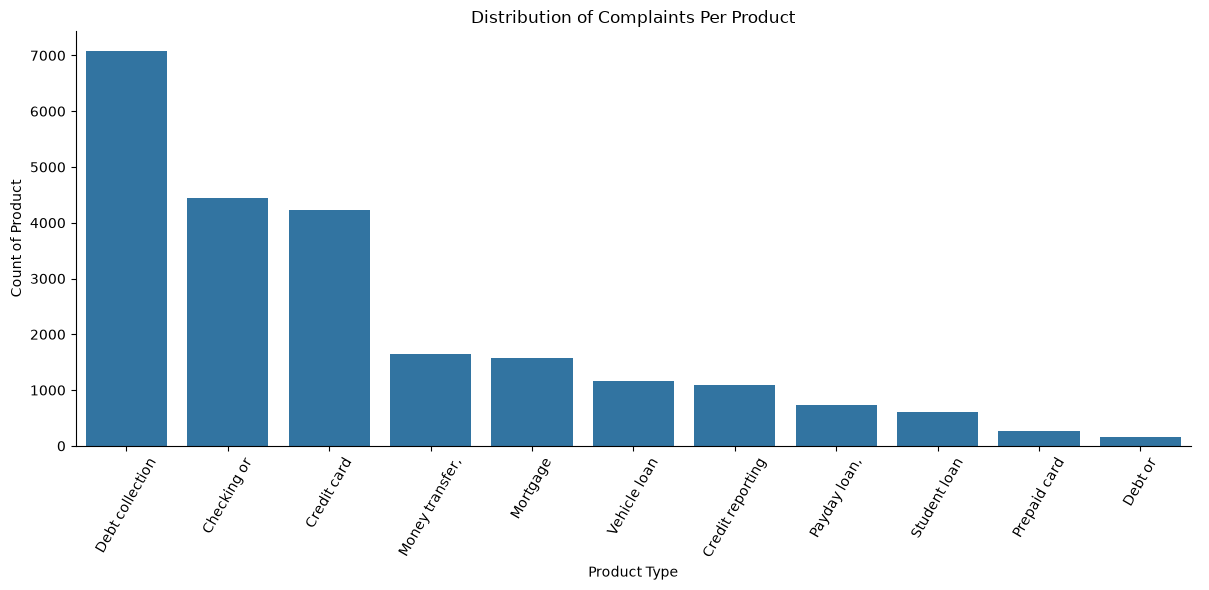

In [12]:
g = sns.catplot(
    x=product_counts.index,
    y=product_counts.values, 
    kind="bar", height=6, aspect=2,
)
plt.title("Distribution of Complaints Per Product")
g.set_xlabels(label="Product Type")
g.set_ylabels(label="Count of Product")
g.set_xticklabels(rotation=60)
plt.tight_layout()

***COMMENT 1: WHICH PRODUCT/CATEGORY HAS THE MOST COMPLAINTS?*** The plot shows that Debt collection, Checking or savings account, and Credit card being the product with most complaints out of the 11 products. These categories could be collapsed into a more concise set of products attributed to a particular unit/department.

---

In [13]:
df['timely'].value_counts()

timely
Yes    22276
No       692
Name: count, dtype: int64

In [14]:
# which complaints were mostly not responded to in a timely manner
df[df['timely']=='No']['product'].value_counts()

product
Student loan                                               222
Debt collection                                            219
Credit card                                                 49
Payday loan, title loan, personal loan, or advance loan     45
Mortgage                                                    40
Money transfer, virtual currency, or money service          36
Prepaid card                                                27
Checking or savings account                                 21
Vehicle loan or lease                                       19
Debt or credit management                                   11
Credit reporting or other personal consumer reports          3
Name: count, dtype: int64

***COMMENT 2: WERE COMPLAINTS RESPONDED TO IN A TIMELY MANNER AND WHICH COMPLAINTS MOSTLY SUFFERED FROM UNTIMELY RESPONSE?*** Over 95% of the cases during this period were responded to in a timely manner. However, per dataset we do not know the reasons for the delay and how long it took to address complaints that were not timely responded to. This is also a justification to build a route system to monitor which teams/departments received such complaints.

Student loan and Debt collection (which could broadly be classified as credit facilities) lead in terms of untimely response, occupying more than 60% of untimely responses. This could be due to somewhat "complexity/ verification/bureaucracies" associated with such products.

---

In [15]:
# group companies by the number of unique products for the complaints.
companies_unique_products = df.groupby("company")['product'].nunique().sort_values()
companies_unique_products

company
Yamaha Motor Finance Corporation USA       1
YSA ARM LLC DBA Oxygen XL                  1
WorldRemit Corp.                           1
AMA Advisors, LLC.                         1
AMERINATIONAL COMMUNITY SERVICES, INC.     1
                                          ..
FIFTH THIRD FINANCIAL CORPORATION          9
CAPITAL ONE FINANCIAL CORPORATION          9
BANK OF AMERICA, NATIONAL ASSOCIATION     10
CITIBANK, N.A.                            10
WELLS FARGO & COMPANY                     11
Name: product, Length: 1148, dtype: int64

In [16]:
companies_unique_products.head(10)

company
Yamaha Motor Finance Corporation USA      1
YSA ARM LLC DBA Oxygen XL                 1
WorldRemit Corp.                          1
AMA Advisors, LLC.                        1
AMERINATIONAL COMMUNITY SERVICES, INC.    1
AMERISAVE MORTGAGE CORPORATION            1
AR Resources, Inc.                        1
AR Solutions Inc                          1
ADS Resolve LLC                           1
ALCAR INC.                                1
Name: product, dtype: int64

In [17]:
# percentage of total companies that have complaints about only 1 product category
companies_with_one_product = sum(companies_unique_products==1)
total_companies = len(companies_unique_products)
print(f"Percentage of total companies with complaints associated with only one product category: {(companies_with_one_product/total_companies)*100:.2f}%")

Percentage of total companies with complaints associated with only one product category: 72.65%


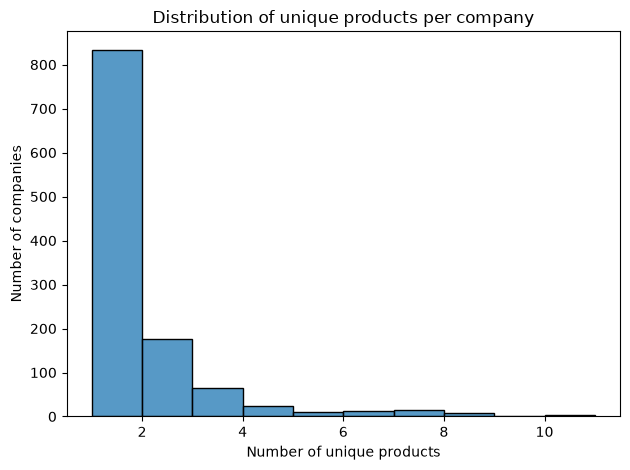

In [18]:
sns.histplot(x=companies_unique_products.values, bins=10)
plt.title("Distribution of unique products per company")
plt.xlabel("Number of unique products")
plt.ylabel("Number of companies")
plt.tight_layout()
plt.show()

In [19]:
# check if a company that has complaints from one product.
df[df['company']=="WorldRemit Corp."]

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue
575,"Money transfer, virtual currency, or money ser...","I deposited {$13000.00} in my XXXX wallet, mon...",2026-05-04T15:34:48.000Z,Other transaction problem,International money transfer,10453,None,21852923,Yes,Closed with monetary relief,Web,WorldRemit Corp.,2026-05-04T15:20:50.000Z,NY,None,None
5703,"Money transfer, virtual currency, or money ser...",My account was deactivated without stating a c...,2026-05-13T23:43:00.000Z,Other service problem,International money transfer,802XX,None,22181629,No,Closed with explanation,Web,WorldRemit Corp.,2026-05-13T23:13:20.000Z,CO,None,None
17019,"Money transfer, virtual currency, or money ser...",I am filing a complaint against XXXX regarding...,2026-06-02T18:31:31.000Z,Confusing or missing disclosures,Foreign currency exchange,20912,None,22815814,Yes,Closed with explanation,Web,WorldRemit Corp.,2026-06-02T18:20:52.000Z,MD,None,None


***COMMENT 3: ASSUMING THE MODEL TO BE BUILT WILL CONTAIN COMPANIES, DO WE HAVE COMPANIES THAT HAVE A SINGLE COMPLAINT PER PRODUCT?***  

Building a model with companies as a feature could lead to the model "learning" to attribute certain products to specific companies because such companies only have that product type. This could lead to overfitting during model development. An example is shown above for a company such as "WorldRemit Corp." which is widely known/associated with Money transfer, virtual currency. 

The histogram further shows that lots of the companies have a single product associated with reported complaints. Per the data, the Percentage of total companies with complaints associated with only one product category is 72.65%.

---

In [20]:
# randomly print 3 complaints to explore
for idx, text in enumerate(df.sample(3, random_state=42)['complaint_what_happened'].to_list()):
    print(f"TEXT {idx+1}:\n{text}\n\n")

TEXT 1:
b'I never used the service. I received faulty equipment that didnt work.'


TEXT 2:
XXXX XXXX XXXX XXXX XXXX XXXX XXXX, Alabama XXXX Date of Birth : XX/XX/XXXX Last Four SSN : XXXX Subject : Formal Dispute, Request for Method of Verification, and Notice of Potential Bankruptcy Violation To Whom It May Concern : I am formally disputing the accuracy, completeness, and legality of an account being reported by XXXX XXXX XXXX XXXX. 
This account is currently being collected by XXXX XXXX XXXX ( XXXX ). I have previously requested validation of this debt. While documentation has been provided, it is inconsistent, incomplete, and does not substantiate the account being reported. 
This is not a claim of fraud or identity theft. I am disputing the accuracy and legal validity of the account, and this dispute must not be reclassified or closed as fraud. 
XXXX and XXXX have provided a mixture of documents, including older XXXX XXXX records, later billing and collection documents, and an int

In [21]:
# check length of text
df["length_of_complaint_text"] = df['complaint_what_happened'].apply(lambda x: len(x.split()))

# longest complaint text
longest_text_length = int(df['length_of_complaint_text'].max())
print(f"Longest text length: {longest_text_length}")

# shortest complaint text
shortest_text_length = int(df['length_of_complaint_text'].min())
print(f"Shortest text length: {shortest_text_length}")

# average complaint text
average_text_length = int(df['length_of_complaint_text'].mean())
print(f"Average text length: {average_text_length}")

Longest text length: 5347
Shortest text length: 6
Average text length: 238


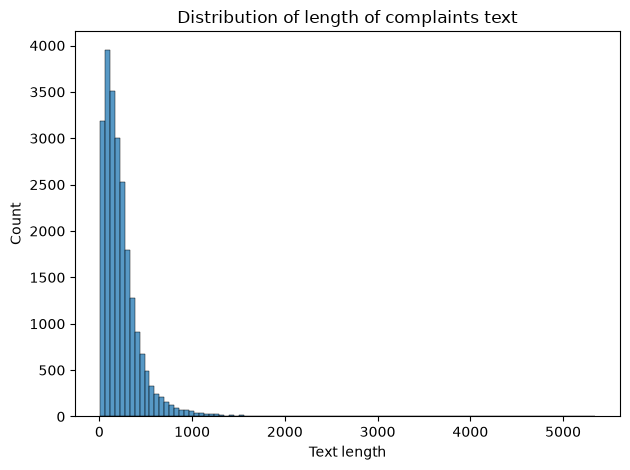

In [22]:
sns.histplot(x=df["length_of_complaint_text"], bins=100)
plt.title("Distribution of length of complaints text")
plt.xlabel("Text length")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [23]:
# longest text
print(df[df['length_of_complaint_text']==df['length_of_complaint_text'].max()]['complaint_what_happened'].values[0])

To evaluate this on purely factual technical data, we have to look at the exact IP address and system details you provided from that email. 

Fact XXXX : The IP Address Can not Be Your Apple Device The IP in the email ( XXXX ) belongs entirely to XXXX XXXX XXXX XXXX XXXX, registered in XXXX, Texas. 
It is a fixed, infrastructure IP block. It does not dynamically assign to, nor can it be controlled by, an XXXX mobile device, an XXXX computer, or an XXXX XXXX XXXX network. 

Fact XXXX : The User Agent is Non-Apple The email strictly notes the device used was " Chrome XXXX / Windows XXXX ''. 
This explicitly specifies a XXXX XXXX operating system operating on a desktop XXXX XXXX web browser version from XX/XX/XXXX. 
This environment is completely separated from the XXXX ecosystem. An XXXX device ( XXXX, XXXX, XXXX ) running official XXXX privacy software will natively output an XXXX XXXX identifier, never a raw XXXX XXXX environment string. 

Fact XXXX : Why the Email Generated Fake Data 

In [24]:
# shortest text in dataset
df[df['length_of_complaint_text']==df['length_of_complaint_text'].max()]

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue,length_of_complaint_text
5262,Checking or savings account,To evaluate this on purely factual technical d...,2026-07-07T01:36:12.000Z,Closing an account,Checking account,94605,None,22195409,Yes,Closed with explanation,Web,UNITED SERVICES AUTOMOBILE ASSOCIATION,2026-05-14T11:07:51.000Z,CA,Company has responded to the consumer and the ...,Funds not received from closed account,5347


In [25]:
# check average text length per product category
avg_text_length_per_product = round(df.groupby("product")['length_of_complaint_text'].mean().sort_values(ascending=False))

# shorten the name for the plot
avg_text_length_per_product.index = [" ".join(name.split()[:2]) for name in avg_text_length_per_product.index]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19676\517394569.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(labels=avg_text_length_per_product.index,rotation=60)


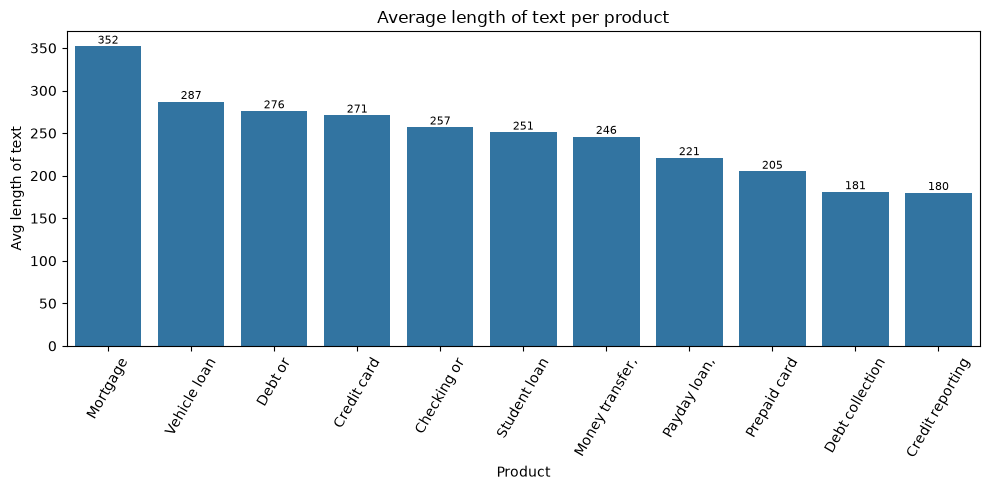

In [26]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=avg_text_length_per_product.index,
                 y=avg_text_length_per_product.values,
                estimator="sum", errorbar=None)
ax.bar_label(ax.containers[0], fontsize=8)
ax.set_xlabel("Product")
ax.set_ylabel("Avg length of text")
ax.set_xticklabels(labels=avg_text_length_per_product.index,rotation=60)
plt.title("Average length of text per product")
plt.tight_layout()
plt.show()

***COMMENT 4: TEXT & LENGTH OF TEXT OF COMPLAINTS?***  

The average length of all complaints was around 240 words. For a coarse breakdown of the length of text per product, Mortgage had the highest average text length of about 352 words. Credit reporting complaints had the lowest average text length, almost half the average of Mortgage text length.

A manual inspection of the complaints text highlighted the scrubbing of vital data from the narratives provided by customers. These are shown by XXXX.

Further, the complaints text should be normalized by cleaning/preprocessing to remove double spacing, new lines etc. This ensures that the dataset is devoid of noise so that the right signals may be captured during modelling.

---

In [27]:
# do last part well and remove duplicates. 
# do wordcloud for one/two products and see if you will find signals 

In [28]:
from wordcloud import WordCloud, STOPWORDS

In [29]:
df['product'].value_counts()

product
Debt collection                                            7078
Checking or savings account                                4437
Credit card                                                4223
Money transfer, virtual currency, or money service         1648
Mortgage                                                   1568
Vehicle loan or lease                                      1158
Credit reporting or other personal consumer reports        1084
Payday loan, title loan, personal loan, or advance loan     736
Student loan                                                602
Prepaid card                                                267
Debt or credit management                                   167
Name: count, dtype: int64

In [30]:
def plot_words(ax, target, df):
    text = " ".join(df[df['product']==target]['complaint_what_happened'].values)
    
    wordcloud = WordCloud(stopwords=STOPWORDS, 
            background_color="black", 
            collocations=False, 
            width=500, 
            height=300).generate(text)
    
    ax.axis("off")
    ax.set_title(target)
    ax.imshow(wordcloud)

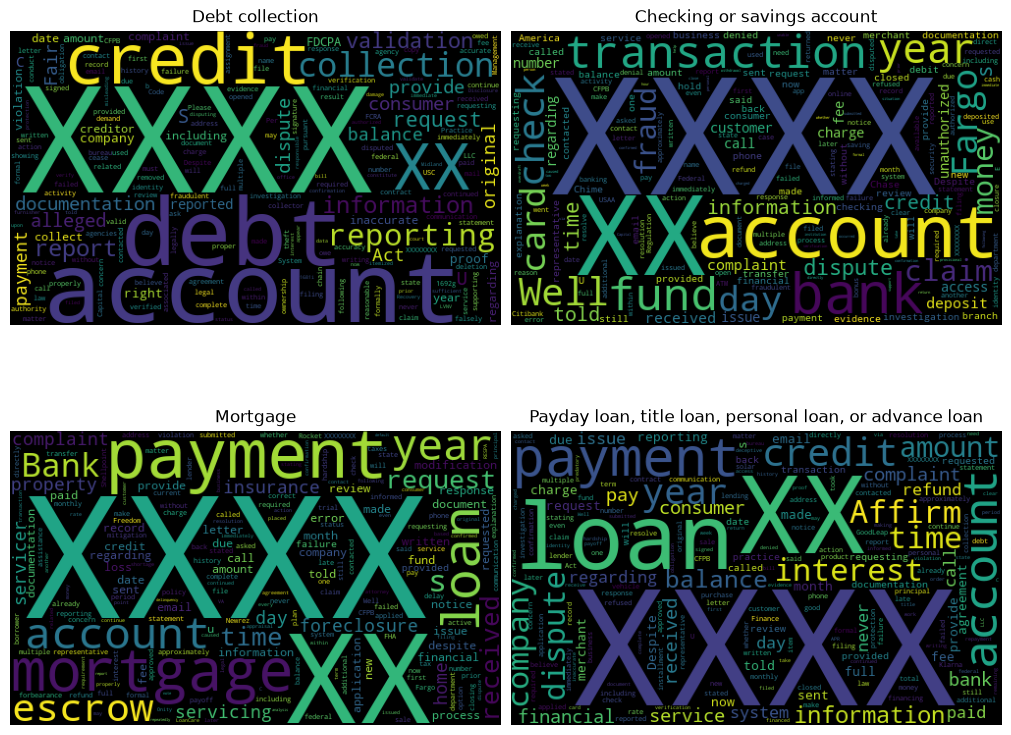

In [31]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2, 2, figsize=(10, 8), layout='constrained')
plot_words(ax0, "Debt collection", df=df)
plot_words(ax1, "Checking or savings account", df=df)
plot_words(ax2, "Mortgage", df=df)
plot_words(ax3, "Payday loan, title loan, personal loan, or advance loan", df=df)

***COMMENT 5: SIGNAL PRESENT IN DATASET?***  

WordCloud boldly shows that the dataset contains lots of XXXX patterns which could genuinely carry signals or could be noisy for the ML models. 

These could be treated by either removing the scrubbing annotations.However, what if they genuinely carry useful information for the models to be built. 

Another way could be to collapse multiple patterns of XXXX into a single pattern eg XXXX XXXX XXXX into only XXXX or [MASK]. This project will use this technique. 

---

In [32]:
print(f"There are {df.shape[0]} total complaints in this dataset")

# complaint_id is the unique id generated for each complaint 
# check if there exist duplicated compliant id

print(f"There are {df.shape[0] - df['complaint_id'].drop_duplicates().shape[0]} duplicated complaint_id(s)")

# checking duplicated complaint text
print(f"Number of complaints after dropping duplicates: {df['complaint_what_happened'].drop_duplicates().shape[0]}")


There are 22968 total complaints in this dataset
There are 0 duplicated complaint_id(s)
Number of complaints after dropping duplicates: 20881


In [33]:
# a look into some of the duplicated text
duplicated_df = df[df['complaint_what_happened'].duplicated()].sort_values(["complaint_what_happened"],ascending=False)
duplicated_df[:2]

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue,length_of_complaint_text
8409,Credit card,please remove fraudulent accounts from my cred...,2026-05-19T18:01:10.000Z,Getting a credit card,General-purpose credit card or charge card,90802,None,22353232,Yes,Closed with explanation,Web,Experian Information Solutions Inc.,2026-05-19T17:58:58.000Z,CA,Company has responded to the consumer and the ...,Card opened without my consent or knowledge,8
9044,Credit card,please remove fraudulent accounts from my cred...,2026-05-19T18:04:35.000Z,Getting a credit card,General-purpose credit card or charge card,90802,None,22353405,Yes,Closed with explanation,Web,"EQUIFAX, INC.",2026-05-19T18:02:54.000Z,CA,None,Card opened without my consent or knowledge,8


In [34]:
# group same complaints text and count number of unique products per unique text

duplicated_df.groupby("complaint_what_happened")['product'].nunique().sort_index(ascending=False)

complaint_what_happened
please remove fraudulent accounts from my credit report                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [35]:
# dropping duplicates
df = df.drop_duplicates(subset="complaint_what_happened")
print(f"Size of dataset: {df.shape[0]}")

Size of dataset: 20881


***COMMENT 7: Duplications in dataset ?***  

Some complaints have the same complaint text however they have different compliant_id's because the issues were raised for different companies.
Many of such examples exist in the dataset, leading to duplicated complaints which is not ideal for the ML models.

Result above shows that dropping duplicated text is justified because for each duplicated text there is a 
single product. Assuming duplicated text were associated with 2 or more products, then it would be somewhat
complicated to know which product to select for that text for modelling.

The step taken is to drop the duplicates.

---



In [36]:
# check if a text is english

detector = LanguageDetectorBuilder.from_languages(Language.ENGLISH).build()
df['is_english'] = df['complaint_what_happened'].apply(lambda x: detector.detect_language_of(x)==Language.ENGLISH)

In [37]:
print("These below were identified as not being ENGLISH: \n")
for text in df[df['is_english']==False]['complaint_what_happened']:
    print(text)

These below were identified as not being ENGLISH: 

XX/XX/year> XXXX  fraud purchase of {$120.00}. XX/XX/year> XXXX XXXX fraud purchase of {$160.00XXXX XXXX XXXX card via XXXX XXXX
XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXXXX/XX/XXXX
I had to make a new XXXX XXXX XXXX account XXXX account got frozen
b'XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX
XX/XX/year>, XXXX, wire transfer through Citibank XXXX XXXX XXXX XX/XX/year>, XXXX, wire transfer through Citibank to XXXX XXXX XX/XX/year>, XXXX USD, wire transfer through Citibank to XXXX XXXX XXXX XXXX, XXXX USD, wire transfer through Citibank to XXXX XXXX XX/XX/XXXX, XXXX, wire transfer through Citibank to XXXX XXXX XXXX XX/XX/year>, XXXX, wire transfer through Citibank to XXXX XXXX XXXX  XX/XX/year>, XXXX, wire transfer through Citibank to XXXX
Unauthorized hold on a Barclays JetBlue credit card.
XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXX

***COMMENT 8: Are all the complaints in English?*** 

All complaints are in English, however, the presence of XXXX and associated patterns was the reason.
This insight shows that for some complaints, only XXXX patterns show up. These complaints might not be useful for the model so such columns complaints will need to be dropped.

---



In [38]:
not_english = df[df['is_english']==False]['complaint_what_happened'].to_list()
not_english

['XX/XX/year> XXXX  fraud purchase of {$120.00}. XX/XX/year> XXXX XXXX fraud purchase of {$160.00XXXX XXXX XXXX card via XXXX XXXX',
 'XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXXXX/XX/XXXX',
 'I had to make a new XXXX XXXX XXXX account XXXX account got frozen',
 "b'XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX",
 'XX/XX/year>, XXXX, wire transfer through Citibank XXXX XXXX XXXX XX/XX/year>, XXXX, wire transfer through Citibank to XXXX XXXX XX/XX/year>, XXXX USD, wire transfer through Citibank to XXXX XXXX XXXX XXXX, XXXX USD, wire transfer through Citibank to XXXX XXXX XX/XX/XXXX, XXXX, wire transfer through Citibank to XXXX XXXX XXXX XX/XX/year>, XXXX, wire transfer through Citibank to XXXX XXXX XXXX  XX/XX/year>, XXXX, wire transfer through Citibank to XXXX',
 'Unauthorized hold on a Barclays JetBlue credit card.',
 'XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX

### **SPLIT AND SAVE DATASET** 

In [39]:
# renaming features
df['product'].value_counts()

product
Debt collection                                            5491
Checking or savings account                                4436
Credit card                                                4168
Money transfer, virtual currency, or money service         1647
Mortgage                                                   1568
Vehicle loan or lease                                      1157
Payday loan, title loan, personal loan, or advance loan     731
Credit reporting or other personal consumer reports         648
Student loan                                                601
Prepaid card                                                267
Debt or credit management                                   167
Name: count, dtype: int64

In [40]:
df['labels'] = df['product'].apply(lambda x: "Collections & Recovery" if x in ["Debt collection", "Debt or credit management"] 
                    else "Banking Operations" if x=="Checking or savings account"
                    else "Cards & Payments" if x in ["Credit card", "Prepaid card"]
                    else "Consumer Lending" if x in ["Vehicle loan or lease", "Payday loan, title loan, personal loan, or advance loan", "Student loan"]
                    else "Money Transfer and Payments" if x=="Money transfer, virtual currency, or money service"
                    else "Mortgage & Home Lending" if x=="Mortgage"
                    else "Credit Reporting & Disputes" if x=="Credit reporting or other personal consumer reports"
                    else "INCORRECT MAPPING")
df.head(1)

,product,complaint_what_happened,date_sent_to_company,issue,sub_product,zip_code,tags,complaint_id,timely,company_response,submitted_via,company,date_received,state,company_public_response,sub_issue,length_of_complaint_text,is_english,labels
0,Credit card,"If you can not provide verifiable proof, inclu...",2026-05-03T04:25:21.000Z,Getting a credit card,General-purpose credit card or charge card,33027,None,21831557,Yes,Closed with explanation,Web,"BANK OF AMERICA, NATIONAL ASSOCIATION",2026-05-03T04:18:57.000Z,FL,Company has responded to the consumer and the ...,Card opened without my consent or knowledge,168,True,Cards & Payments


In [41]:
from sklearn.model_selection import train_test_split

In [43]:
# remove length of text before saving
# remove is_english
df.drop(["length_of_complaint_text", "is_english"], inplace=True, axis=1)

In [44]:
# test
to_split, test_set = train_test_split(df, test_size=0.15,random_state=42, stratify=df['labels'])

# train and val
train_set, val_set = train_test_split(to_split, test_size=0.2,random_state=42, stratify=to_split['labels'])

print(f"Train: {train_set.shape[0]}")
print(f"Val: {val_set.shape[0]}")
print(f"Test: {test_set.shape[0]}")

Train: 14198
Val: 3550
Test: 3133


In [45]:
# save dataset

train_set.to_csv("../datasets/train.csv", index=False)
val_set.to_csv("../datasets/val.csv", index=False)
test_set.to_csv("../datasets/test.csv", index=False)